# 문화 온도(Culture Temperature) EDA (Neo4j 기반)

## 목적
Neo4j에 저장된 매물과 문화시설 간의 연결 정보(500m 반경)를 기반으로,
매물 주변 문화시설 **개수**에 따른 점수 산정 기준을 수립합니다.

## 분석 대상
- **노드**: `Property`, `Culture`
- **관계**: `(:Property)-[:NEAR_CULTURE]->(:Culture)` (distance < 500m 이미 연결됨)

In [2]:
import os
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from neo4j import GraphDatabase
from dotenv import load_dotenv

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# Root 경로 설정 및 Config 불러오기
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, "../../.."))
sys.path.append(os.path.join(project_root, "scripts", "data_import"))

from config import Config

# .env 로드 (API Key 등)
load_dotenv(os.path.join(project_root, ".env"))

로컬 환경 감지: c:\dev\study\team_project\Final Project\SKN18-FINAL-1TEAM\data\GraphDB_data 사용


True

## 1. Neo4j 데이터 로드
매물별로 연결된 문화시설의 개수(Count)를 가져옵니다.
연결이 없는 매물도 포함하기 위해 `OPTIONAL MATCH`를 사용하거나, 전체 매물 수 대비 비율을 계산합니다.

In [3]:
class Neo4jConnector:
    def __init__(self):
        # localhost로 변경!
        self.driver = GraphDatabase.driver(
            "bolt://localhost:7687", 
            auth=("neo4j", "password123")  # 본인 비밀번호
        )
    
    def get_culture_counts(self, limit=10000):
        query = """
        MATCH (p:Property)
        OPTIONAL MATCH (p)-[r:NEAR_CULTURE]->(c:Culture)
        WHERE r.distance <= 500
        RETURN p.id as property_id, c.category as category, count(c) as count
        LIMIT $limit
        """
        with self.driver.session() as session:
            result = session.run(query, limit=limit)
            return pd.DataFrame([r.data() for r in result])
    
    def close(self):
        self.driver.close()

db = Neo4jConnector()
df = db.get_culture_counts(limit=10000)
db.close()

print(f"분석 대상 매물 수: {len(df)}")

분석 대상 매물 수: 10000


In [4]:
db = Neo4jConnector()
df = db.get_culture_counts(limit=10000)
db.close()

# 컬럼명 변경 (여기에 추가)
df = df.rename(columns={'count': 'culture_count'})

print(f"분석 대상 매물 수: {len(df)}")

분석 대상 매물 수: 10000


## 2. 분포 분석
매물 주변(500m) 문화시설 개수의 분포를 확인합니다.

=== 기술 통계 ===
count    10000.000000
mean         1.116000
std          0.886918
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         20.000000
Name: culture_count, dtype: float64

0개인 매물 비율: 16.5%
1개 이상 매물 비율: 83.5%


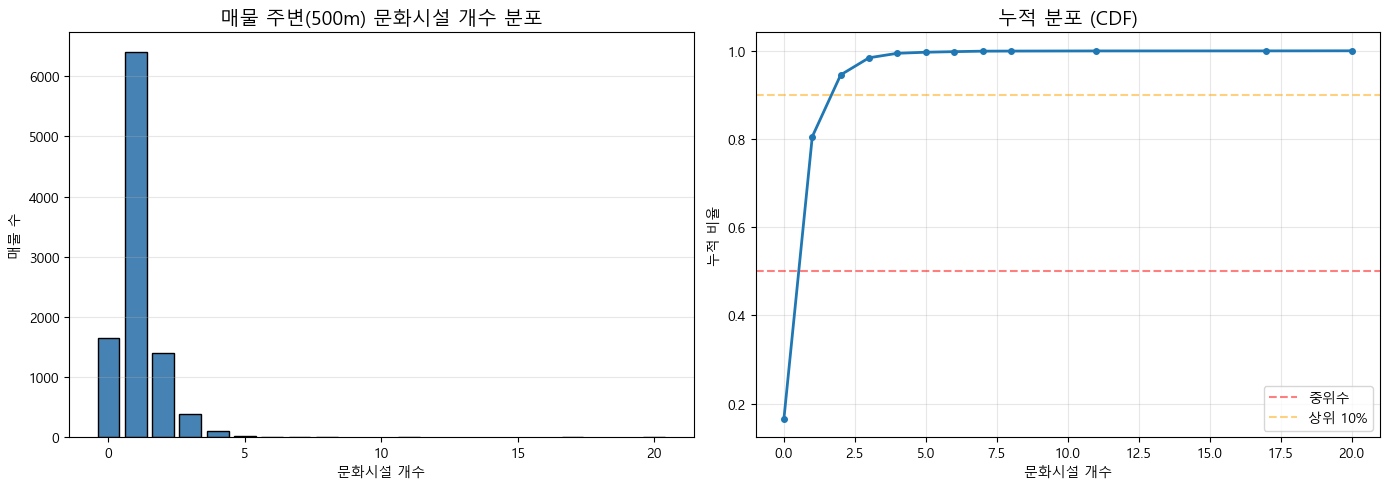

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 기술 통계
print("=== 기술 통계 ===")
print(df['culture_count'].describe())
print(f"\n0개인 매물 비율: {(df['culture_count'] == 0).mean()*100:.1f}%")
print(f"1개 이상 매물 비율: {(df['culture_count'] >= 1).mean()*100:.1f}%")

# 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
ax1 = axes[0]
counts = df['culture_count'].value_counts().sort_index()
ax1.bar(counts.index, counts.values, color='steelblue', edgecolor='black')
ax1.set_title('매물 주변(500m) 문화시설 개수 분포', fontsize=14)
ax1.set_xlabel('문화시설 개수')
ax1.set_ylabel('매물 수')
ax1.grid(axis='y', alpha=0.3)

# 누적 분포 (CDF)
ax2 = axes[1]
sorted_data = df['culture_count'].sort_values()
cdf = [(sorted_data <= x).mean() for x in sorted_data.unique()]
ax2.plot(sorted_data.unique(), cdf, marker='o', linewidth=2, markersize=4)
ax2.set_title('누적 분포 (CDF)', fontsize=14)
ax2.set_xlabel('문화시설 개수')
ax2.set_ylabel('누적 비율')
ax2.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='중위수')
ax2.axhline(y=0.9, color='orange', linestyle='--', alpha=0.5, label='상위 10%')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. 점수화 로직 제안
- **개수 기반 점수**: 특정 개수 이상이면 만점(예: 3개 이상 100점).
- **구간별 점수**: 0개=0점, 1개=50점, 2개=80점, 3개 이상=100점 등.

### 분포 기반 제안
하위, 중위, 상위 분포를 보고 '적절한 만점 기준'을 정합니다.
예를 들어 상위 10%의 매물이 2개 이상의 시설을 가지고 있다면, 3개를 만점으로 설정하는 식입니다.

In [6]:
print(df.columns.tolist())

['property_id', 'category', 'culture_count']


In [7]:
# 컬럼명 변경
df = df.rename(columns={'count': 'culture_count'})

# 이제 분석 가능
print(df['culture_count'].describe())

count    10000.000000
mean         1.116000
std          0.886918
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         20.000000
Name: culture_count, dtype: float64


=== 분위수별 개수 ===
상위 50% (p50): 1.0개
상위 25% (p75): 1.0개
상위 10% (p90): 2.0개
상위 5% (p95): 3.0개
상위 1% (p99): 4.0개

만점 기준 3개일 때 평균 점수: 36.1점


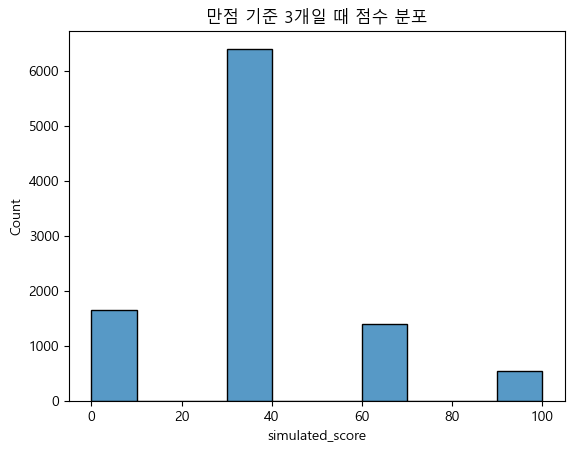

In [8]:
# 분위수 확인
percentiles = [0.5, 0.75, 0.9, 0.95, 0.99]
print("=== 분위수별 개수 ===")
for p in percentiles:
    val = df['culture_count'].quantile(p)
    print(f"상위 {(1-p)*100:.0f}% (p{int(p*100)}): {val}개")

# 시뮬레이션: 만약 3개 이상이면 100점이라면?
max_criteria = 3
df['simulated_score'] = df['culture_count'].apply(lambda x: min(100, (x / max_criteria) * 100))

print(f"\n만점 기준 {max_criteria}개일 때 평균 점수: {df['simulated_score'].mean():.1f}점")
sns.histplot(df['simulated_score'], bins=10)
plt.title(f'만점 기준 {max_criteria}개일 때 점수 분포')
plt.show()

In [9]:
"""
문화 온도 가중치 비교: 현재 vs 도서관 5점
"""
from neo4j import GraphDatabase

# Neo4j 연결
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "password123"))

with driver.session() as session:
    result = session.run("""
    MATCH (p:Property)
    WITH p LIMIT 500  // 샘플링
    
    // 1. 현재 버전 (도서관 10점)
    OPTIONAL MATCH (p)-[r:NEAR_CULTURE]->(c:Culture)
    WHERE r.distance <= 500
    WITH p, c, r,
         CASE c.category
            WHEN '영화관' THEN 30 * (1 - r.distance / 500.0)
            WHEN '미술관' THEN 30 * (1 - r.distance / 500.0)
            WHEN '공연장' THEN 25 * (1 - r.distance / 500.0)
            WHEN '박물관/기념관' THEN 15 * (1 - r.distance / 500.0)
            WHEN '도서관' THEN 10 * (1 - r.distance / 500.0)  // 현재: 10점
            ELSE 10 * (1 - r.distance / 500.0)
         END as score_v1,
         CASE c.category
            WHEN '영화관' THEN 30 * (1 - r.distance / 500.0)
            WHEN '미술관' THEN 30 * (1 - r.distance / 500.0)
            WHEN '공연장' THEN 25 * (1 - r.distance / 500.0)
            WHEN '박물관/기념관' THEN 15 * (1 - r.distance / 500.0)
            WHEN '도서관' THEN 5 * (1 - r.distance / 500.0)   // 변경: 5점
            ELSE 5 * (1 - r.distance / 500.0)
         END as score_v2
    
    WITH p.id as property_id,
         sum(score_v1) as total_v1,
         sum(score_v2) as total_v2
    
    RETURN 
        avg(total_v1) as avg_score_current,
        avg(total_v2) as avg_score_library5,
        avg(total_v1 - total_v2) as avg_diff,
        percentileCont(total_v1, 0.5) as median_current,
        percentileCont(total_v2, 0.5) as median_library5,
        max(total_v1) as max_current,
        max(total_v2) as max_library5
    """)
    
    record = result.single()
    
    print("=" * 60)
    print("📊 문화 온도 가중치 비교 결과")
    print("=" * 60)
    print(f"\n{'지표':<25} {'현재 (도서관 10점)':<20} {'변경 (도서관 5점)':<20}")
    print("-" * 65)
    print(f"{'평균 점수':<25} {record['avg_score_current']:.2f}{'':>15} {record['avg_score_library5']:.2f}")
    print(f"{'중위수':<25} {record['median_current']:.2f}{'':>15} {record['median_library5']:.2f}")
    print(f"{'최고 점수':<25} {record['max_current']:.2f}{'':>15} {record['max_library5']:.2f}")
    print(f"\n{'평균 차이 (현재 - 변경)':<25} {record['avg_diff']:.2f}점")
    print("=" * 60)

driver.close()

📊 문화 온도 가중치 비교 결과

지표                        현재 (도서관 10점)         변경 (도서관 5점)         
-----------------------------------------------------------------
평균 점수                     13.50                11.08
중위수                       8.02                4.40
최고 점수                     83.90                77.19

평균 차이 (현재 - 변경)           2.42점
